In [33]:
import pandas as pd
path = "/home/lakshmi-sweatha-pasupuleti/Projects/mini_competition_grocery_sales_forecast/data/raw/favorita-grocery-sales-forecasting/train.csv"


sample_parts = []
rows_needed = 100_000

for chunk in pd.read_csv(
    path,
    parse_dates=["date"],
    chunksize=500_000
):

    # Keep latest-year rows
    recent = chunk[
        chunk["date"] >= "2016-08-15"
    ][
        ["date", "store_nbr", "item_nbr", "unit_sales"]
    ]

    if len(recent) > 0:
        sample_parts.append(recent)

    # Stop once we have enough rows
    current_rows = sum(len(x) for x in sample_parts)

    if current_rows >= rows_needed:
        break


# Combine the small pieces
sample_train_data = pd.concat(
    sample_parts,
    ignore_index=True
)

# Keep exactly 100,000 rows
sample_train_data = sample_train_data.iloc[:rows_needed].copy()


# --------------------------------------------------
# 3. Check what we loaded
# --------------------------------------------------

print("Rows:", len(sample_train_data))
print("Date range:")
print(sample_train_data["date"].min())
print(sample_train_data["date"].max())

print("\nShape:")
print(sample_train_data.shape)

print("\nColumns:")
print(sample_train_data.columns.tolist())

/tmp/ipykernel_142165/1639035830.py:8: DtypeWarning: Columns (0: onpromotion) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(


Rows: 100000
Date range:
2016-08-15 00:00:00
2016-08-16 00:00:00

Shape:
(100000, 4)

Columns:
['date', 'store_nbr', 'item_nbr', 'unit_sales']


In [34]:
store_item_pattern = (
    sample_train_data
    .groupby(["store_nbr", "item_nbr"])["unit_sales"]
    .agg(
        total_sales="sum",
        average_sales="mean",
        median_sales="median",
        observations="count"
    )
    .sort_values("total_sales", ascending=False)
)

print(store_item_pattern.head(20))

                    total_sales  average_sales  median_sales  observations
store_nbr item_nbr                                                        
39        1167614      2047.000      2047.0000     2047.0000             1
44        1503844       617.204       617.2040      617.2040             1
49        1503844       556.612       556.6120      556.6120             1
44        1430040       556.000       556.0000      556.0000             1
35        1167614       534.000       534.0000      534.0000             1
3         1047679       508.000       508.0000      508.0000             1
44        1047679       497.000       497.0000      497.0000             1
51        1642399       472.983       472.9830      472.9830             1
3         1503844       443.745       443.7450      443.7450             1
44        1642399       428.780       428.7800      428.7800             1
45        1503844       416.500       416.5000      416.5000             1
44        1473474       4

In [35]:
pairs = sample_train_data[
    ["store_nbr", "item_nbr"]
].drop_duplicates().head(100)

print(pairs)

selected = []

for chunk in pd.read_csv(
    path,
    parse_dates=["date"],
    chunksize=500_000
):

    recent = chunk[
        chunk["date"] >= "2016-08-15"
    ][
        ["date", "store_nbr", "item_nbr", "unit_sales"]
    ]

    matched = recent.merge(
        pairs,
        on=["store_nbr", "item_nbr"],
        how="inner"
    )

    if len(matched) > 0:
        selected.append(matched)

selected = pd.concat(selected, ignore_index=True)

    store_nbr  item_nbr
0           1    103665
1           1    105574
2           1    105575
3           1    105577
4           1    105693
..        ...       ...
95          1    208699
96          1    209085
97          1    210520
98          1    210798
99          1    211203

[100 rows x 2 columns]


/tmp/ipykernel_142165/3936395017.py:9: DtypeWarning: Columns (0: onpromotion) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(


In [36]:
selected.groupby(
    ["store_nbr", "item_nbr"]
).size()

store_nbr  item_nbr
1          103665      275
           105574      340
           105575      364
           105577      186
           105693       99
                      ... 
           208699      236
           209085      154
           210520      138
           210798      233
           211203      362
Length: 100, dtype: int64

In [37]:
example = selected[
    (selected["store_nbr"] == 1) &
    (selected["item_nbr"] == 211203)
].sort_values("date")

            date  store_nbr  item_nbr  unit_sales
99    2016-08-15          1    211203         5.0
179   2016-08-16          1    211203         8.0
258   2016-08-17          1    211203        10.0
340   2016-08-18          1    211203         7.0
420   2016-08-19          1    211203        12.0
...          ...        ...       ...         ...
25875 2017-08-11          1    211203         4.0
25935 2017-08-12          1    211203         8.0
25974 2017-08-13          1    211203         5.0
26047 2017-08-14          1    211203        11.0
26112 2017-08-15          1    211203        13.0

[362 rows x 4 columns]


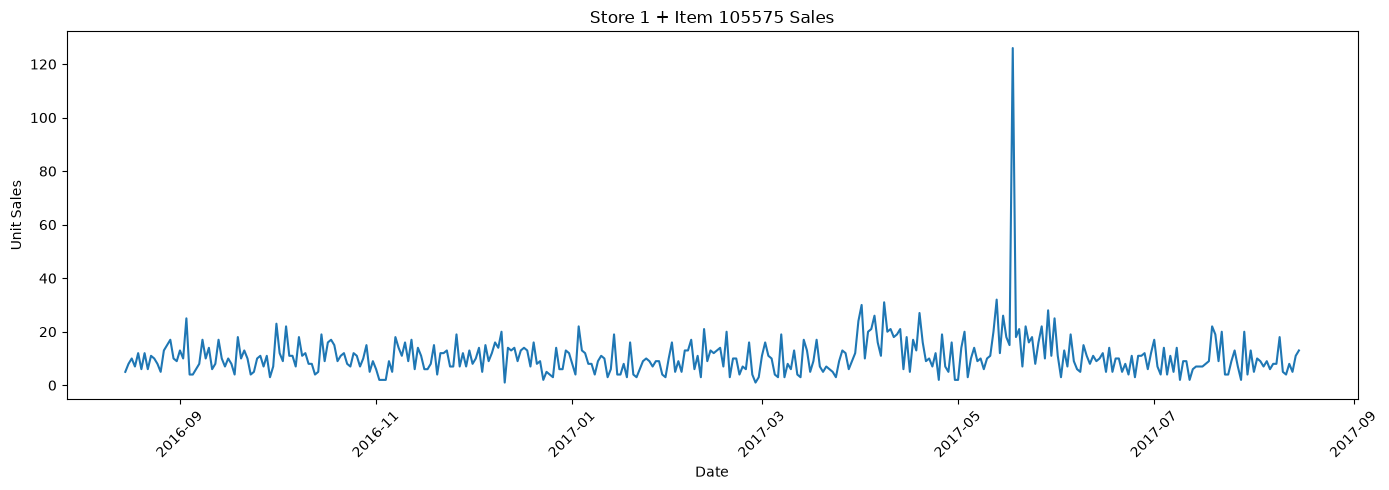

In [38]:
print(example)

import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

plt.plot(
    example["date"],
    example["unit_sales"]
)

plt.title("Store 1 + Item 105575 Sales")
plt.xlabel("Date")
plt.ylabel("Unit Sales")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [39]:
print(example["unit_sales"].autocorr(lag=1))
print(example["unit_sales"].autocorr(lag=7))

0.10215616978223599
0.11883625258411452


In [40]:
lag_results = []

for (store, item), group in selected.groupby(
    ["store_nbr", "item_nbr"]
):
    group = group.sort_values("date")

    lag1 = group["unit_sales"].autocorr(lag=1)
    lag7 = group["unit_sales"].autocorr(lag=7)

    lag_results.append({
        "store_nbr": store,
        "item_nbr": item,
        "observations": len(group),
        "lag1_corr": lag1,
        "lag7_corr": lag7
    })

lag_results = pd.DataFrame(lag_results)

lag_results

,store_nbr,item_nbr,observations,lag1_corr,lag7_corr
0,1,103665,275,-0.104728,-0.096317
1,1,105574,340,0.141965,0.261913
2,1,105575,364,0.063371,0.117554
3,1,105577,186,-0.131926,-0.056976
4,1,105693,99,0.197504,-0.086940
...,...,...,...,...,...
95,1,208699,236,0.062833,0.067768
96,1,209085,154,0.020270,0.027341
97,1,210520,138,-0.074957,0.052837
98,1,210798,233,0.120762,0.040544


In [41]:
selected = selected.sort_values(
    ["store_nbr", "item_nbr", "date"]
)

selected["rolling_7"] = (
    selected
    .groupby(["store_nbr", "item_nbr"])["unit_sales"]
    .transform(lambda x: x.shift(1).rolling(7).mean())
)

selected["rolling_28"] = (
    selected
    .groupby(["store_nbr", "item_nbr"])["unit_sales"]
    .transform(lambda x: x.shift(1).rolling(28).mean())
)

In [42]:
selected[[
    "unit_sales",
    "rolling_7",
    "rolling_28"
]].corr()

,unit_sales,rolling_7,rolling_28
unit_sales,1.000000,0.608327,0.584137
rolling_7,0.608327,1.000000,0.888197
rolling_28,0.584137,0.888197,1.000000
